In [1]:
from dotenv import load_dotenv
load_dotenv()

True

### 사용자가 입력한 키워드에 대한 뉴스 검색 함수

In [2]:
from tavily import TavilyClient
from langchain_core.tools import tool

tavily_client = TavilyClient()

def search_recent_news(keyword):
    """
    This tool interacts with the Tavily AI API to search for recent news articles related to a given keyword.

    Args:
        keyword (str): The keyword or phrase to search for in the news articles.

    Returns:
        list: 
        A list of titles, each containing up to 10 of the most recent news articles related to the keyword.
        - 'title' (str): The title of the news article.

    Example:
        response = search_news("OpenAI")
        # Returns a list of news articles published in the last day related to OpenAI.
    """
    article_info = []
    # search의 return값이 ["results]
    response = tavily_client.search(
        query=keyword,
        max_results=10,
        topic="news", 
        days=7
    )
    # response에는 title, url, content가 있다.
    title_list = [i["title"] for i in response["results"]]
    return title_list


# @tool
# def search_news(keyword: str):
#     """Search for news articles on the internet"""
#     return tavily_client.search(keyword)

In [3]:
# 제목만 반환. 
keyworld = "OpenAI"
result = search_recent_news(keyworld)
result


['OpenAI to present plans for U.S. AI strategy and an alliance to compete with China - CNBC',
 "OpenAI's lawyer says there are too many files from Ilya Sutskever and other employees to share in copyright lawsuit - Business Insider",
 'OpenAI reportedly facing issues with its new AI model is a red flag for the entire industry - Business Insider',
 "OpenAI's Chief Safety Researcher Lillian Wen resigns, marking the first wave of AI safety leaders to leave the company - GIGAZINE（ギガジン）",
 "Elon Musk says OpenAI's compensation is 'lavish.' Here's how much employees get paid. - Business Insider",
 "OpenAI plans to release an AI agent called 'Operator' to operate PCs on behalf of humans in January 2025 - GIGAZINE（ギガジン）",
 'ChatGPT rejected more than 250,000 image generations of presidential candidates prior to Election Day - NBC News',
 'OpenAI reportedly developing new strategies to deal with AI improvement slowdown - TechCrunch',
 'OpenAI co-founder Greg Brockman returns three months after l

### 뉴스테마 설정 함수

In [4]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Data model
class NewsletterThemeOutput(BaseModel):
    """Output model for structured theme and sub-theme generation."""

    theme: str = Field(
        description="The main newsletter theme based on the provided article titles."
    )
    sub_themes: list[str] = Field(
        description="List of sub-themes or key news items to investigate under the main theme, ensuring they are specific and researchable."
    )

structured_llm_newsletter = llm.with_structured_output(NewsletterThemeOutput)

# prompt
system = """
# main theme
You are an expert helping to create a newsletter. 
Based on a list of article titles provided, your task is to choose a single, 
specific newsletter theme framed as a clear, detailed question that grabs the reader's attention. 

# sub themes
In addition, generate 5 sub-themes that are highly specific, researchable news items or insights under the main theme. 
Ensure these sub-themes reflect the latest trends in the field and frame them as compelling news topics.

The output should be formatted as:
- Main theme (in question form)
- 3-5 sub-themes (detailed and focused on emerging trends, technologies, or insights).

The sub-themes should create a clear direction for the newsletter, avoiding broad, generic topics.
All your output should be in Korean

"""

# This is the template that will feed in to the structured LLM.
theme_prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    ("human", "Article titles: \n\n {article_titles}")
])

newsletter_generator = theme_prompt | structured_llm_newsletter

In [5]:
# news를 검색한 결과를 articles_titles로 적어준다.
# keyworld = "OpenAI"
# result = search_recent_news(keyworld)
output = newsletter_generator.invoke({"article_titles": result})
main_theme = output.theme
subthemes = output.sub_themes

In [6]:
output

NewsletterThemeOutput(theme='AI 산업의 미래: OpenAI의 전략과 도전은 무엇인가?', sub_themes=['OpenAI의 미국 AI 전략 발표: 중국과의 경쟁에서의 새로운 동맹은 무엇을 의미하는가?', 'AI 안전성 리더의 이탈: Lillian Wen의 사임이 OpenAI와 AI 산업에 미치는 영향은?', 'OpenAI의 새로운 AI 모델 문제: 산업 전반에 걸친 경고 신호는 무엇인가?', "2025년 출시 예정인 OpenAI의 'Operator': 인간을 대신해 PC를 운영하는 AI 에이전트의 가능성과 도전은?", 'OpenAI의 보상 체계: 직원 급여가 AI 산업의 경쟁력에 미치는 영향은?'])

In [7]:
subthemes

['OpenAI의 미국 AI 전략 발표: 중국과의 경쟁에서의 새로운 동맹은 무엇을 의미하는가?',
 'AI 안전성 리더의 이탈: Lillian Wen의 사임이 OpenAI와 AI 산업에 미치는 영향은?',
 'OpenAI의 새로운 AI 모델 문제: 산업 전반에 걸친 경고 신호는 무엇인가?',
 "2025년 출시 예정인 OpenAI의 'Operator': 인간을 대신해 PC를 운영하는 AI 에이전트의 가능성과 도전은?",
 'OpenAI의 보상 체계: 직원 급여가 AI 산업의 경쟁력에 미치는 영향은?']

### 함수화

In [8]:
from typing import List

def subtheme_generator(recent_news: List[str]):
    """
    최신 뉴스 검색 기사들. List형식으로 받을것이다.
    """
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    # Data Model
    class NewsletterThemeOutput(BaseModel):
        theme: str = Field(
            description="The main newsletter theme based on the provided article titles."
        )
        sub_themes: list[str] = Field(
            description="List of sub-themes or key news items to investigate under the main theme, ensuring they are specific and researchable."
        )

    # LLM with function call
    structured_llm_newsletter = llm.with_structured_output(NewsletterThemeOutput)

    # Prompt
    system = """
    # main theme
    You are an expert helping to create a newsletter. Based on a list of article titles provided, your task is to choose a single, 
    specific newsletter theme framed as a clear, detailed question that grabs the reader's attention. 

    # sub themes
    In addition, generate 3 to 5 sub-themes that are highly specific, researchable news items or insights under the main theme. 
    Ensure these sub-themes reflect the latest trends in the field and frame them as compelling news topics.

    The output should be formatted as:
    - Main theme (in question form)
    - 3-5 sub-themes (detailed and focused on emerging trends, technologies, or insights).

    The sub-themes should create a clear direction for the newsletter, avoiding broad, generic topics.
    All your output should be in Korean

    """

    theme_prompt = ChatPromptTemplate.from_messages([
        ("system", system),
        ("human", "Article titles: \n\n {recent_news}")
    ])

    newsletter_generator = theme_prompt | structured_llm_newsletter
    output = newsletter_generator.invoke({"recent_news": recent_news})
    return output


In [9]:
# news를 검색한 결과를 articles_titles로 적어준다.
# keyworld = "OpenAI"
# result = search_recent_news(keyworld)
output = subtheme_generator({"article_titles":result})
subthemes = output.sub_themes
output

NewsletterThemeOutput(theme='AI 산업의 미래: OpenAI의 최근 변화가 우리에게 무엇을 의미하는가?', sub_themes=['OpenAI의 미국 AI 전략 발표: 중국과의 경쟁에서의 새로운 동맹은 무엇인가?', 'AI 안전성 리더의 이탈: Lillian Wen의 사임이 OpenAI와 AI 산업에 미치는 영향은?', 'OpenAI의 새로운 AI 모델 문제: 산업 전반에 걸친 경고 신호는 무엇인가?', "2025년 출시 예정인 OpenAI의 'Operator': 인간을 대신해 PC를 운영하는 AI의 가능성과 도전 과제는?", 'OpenAI의 보상 체계: 직원 급여가 AI 산업의 경쟁력에 미치는 영향은?'])

### **세부 뉴스를 비동기로 검색하기**

In [10]:
import asyncio
from tavily import AsyncTavilyClient

async_tavily_client = AsyncTavilyClient()
# search_recent_news
async def search_news_for_subtheme(subtheme):
    """
    세부 주제들을 기반으로 뉴스를 검색하는 비동기 함수
    """
    response = await async_tavily_client.search(
        query=subtheme,
        max_results=5,
        topic="news",
        days=7,
        include_images=True, # 이미지 포함
        include_raw_content=True, # 원본 컨텐츠 포함
    )
    # 각 기사에 맞는 제목, 이미지 내용 추출
    images = response["images"]
    results = response["results"]

    article_info = []
    for i, result in enumerate(results):
        article_info.append({
            "title": result["title"],
            "image_url": images[i],
            "raw_content": result["raw_content"],
        })
    return {subtheme: article_info}

async def search_news_by_subthemes(subthemes):
    """
    여러 세부주제에 대한 뉴스를 비동기로 병렬검색
    """
    # asyncio.gather를 사용해 여러 비동기 작업 병렬 처리
    results = await asyncio.gather(*[search_news_for_subtheme(subtheme) for subtheme in subthemes])
    
    search_results = {}
    for result in results:
        search_results.update(result)

    return search_results

In [11]:
subtheme_search_results = await search_news_by_subthemes(subthemes)
subtheme_search_results

{'OpenAI의 미국 AI 전략 발표: 중국과의 경쟁에서의 새로운 동맹은 무엇인가?': [{'title': 'OpenAI to present plans for U.S. AI strategy and an alliance to compete with China - CNBC',
   'image_url': 'https://cloudfront-us-east-2.images.arcpublishing.com/reuters/OUXSPAPPUVK27H6RHKQWKLT4VI.jpg',
   'raw_content': 'OpenAI to present plans for U.S. AI strategy and an alliance to compete with China\nSkip Navigation\nMarkets\nPre-Markets\nU.S. Markets\nCurrencies\nCryptocurrency\nFutures & Commodities\nBonds\nFunds & ETFs\nBusiness\nEconomy\nFinance\nHealth & Science\nMedia\nReal Estate\nEnergy\nClimate\nTransportation\nIndustrials\nRetail\nWealth\nSports\nLife\nSmall Business\nInvesting\nPersonal Finance\nFintech\nFinancial Advisors\nOptions Action\nETF Street\nBuffett Archive\nEarnings\nTrader Talk\nTech\nCybersecurity\nEnterprise\nInternet\nMedia\nMobile\nSocial Media\nCNBC Disruptor 50\nTech Guide\nPolitics\nWhite House\nPolicy\nDefense\nCongress\nEquity and Opportunity\nVideo\nLatest Video\nFull Episodes\nLivestrea

### 본문 작성 함수

In [12]:
from typing import TypedDict, Annotated, Dict, List
from langgraph.graph import add_messages
from langchain_core.messages import HumanMessage

def merge_dicts(left: Dict, right: Dict) -> Dict:
    return {**left, **right}


class State(TypedDict):
    keyword: str
    article_titles: List[str]
    newsletter_theme: NewsletterThemeOutput
    sub_theme_articles: Dict[str, List[Dict]]
    results: Annotated[Dict[str, str], merge_dicts]
    messages: Annotated[List, add_messages]

In [13]:
async def write_newsletter_section_async(state:State, sub_theme:str) -> Dict:
    articles = state["sub_theme_articles"][sub_theme] # 세부 주제마다 저장되어 있는 뉴스 결과중 특정 세부 주제를 articles에 저장

    # artice_reference = "\n".join(
    #     [f"Title: {article['title']}\n Content: {article['raw_content']}..."
    #      for article in articles]
    # )
    formatted_articles = []
    for article in articles:
        formatted_articles.append(f"Title: {article['title']}\n Content: {article['raw_content']}...")

    article_references = "\n".join(formatted_articles)

    prompt = f"""
    Write a newsletter section for the sub-theme: "{sub_theme}".
    
    Use the following articles as reference and include relevant points from both their titles, images, and content:
    <article>
    {article_references}
    <article/>
    Summarize the key points and trends related to this sub-theme, and ensure you reference the images where they add value to the discussion. 
    Keep the tone engaging and informative for newsletter readers. You should write in Korean
    """

    messages = [HumanMessage(content=prompt)]
    response = llm.invoke(messages)
    return {"resuults": {sub_theme: response.content}}

def write_newsletter_section(state: State, sub_theme: str) -> Dict:
    """병렬처리를 하기 위함."""
    return asyncio.run(write_newsletter_section_async(state, sub_theme))
# 자기 자신을 호출하므로(재귀함수) 무한루프에 빠지게된다.


In [14]:
test_state = {
    'sub_theme_articles': {
        'AI Technology': [
            {
                'title': 'OpenAI Releases GPT-4 Update',
                'raw_content': '''OpenAI has announced a significant update to its GPT-4 model, 
                bringing improvements in reasoning and coding capabilities. The new version shows 
                enhanced performance across various benchmarks and demonstrates better ability 
                to handle complex instructions.'''
            },
            {
                'title': 'AI in Healthcare Makes Breakthrough',
                'raw_content': '''A new AI system has demonstrated remarkable accuracy in early 
                disease detection, potentially revolutionizing preventive healthcare. The system, 
                developed by leading researchers, shows promise in identifying early signs of 
                various conditions.'''
            }
        ]
    },
    'results': {}
}

output = await write_newsletter_section_async(test_state, "AI Technology")
output


{'resuults': {'AI Technology': '### AI 기술 소식\n\n최근 AI 기술 분야에서 두 가지 중요한 발전이 있었습니다. 첫 번째는 OpenAI의 GPT-4 모델 업데이트입니다. OpenAI는 이 모델의 업데이트를 통해 추론 및 코딩 능력을 크게 향상시켰습니다. 새로운 버전은 다양한 벤치마크에서 성능이 개선되었으며, 복잡한 지시사항을 처리하는 능력이 더욱 뛰어난 것으로 나타났습니다. 이와 관련된 이미지는 GPT-4의 성능 향상을 시각적으로 보여주며, AI의 진화가 어떻게 이루어지고 있는지를 잘 설명해줍니다.\n\n두 번째로, AI가 의료 분야에서 혁신적인 breakthroughs를 이루고 있습니다. 최근 개발된 AI 시스템은 조기 질병 탐지에서 놀라운 정확성을 보여주며, 예방 의료의 혁신을 가져올 가능성이 큽니다. 이 시스템은 여러 질병의 초기 징후를 식별하는 데 유망한 성과를 보이고 있으며, 관련 이미지는 AI가 의료 진단에 어떻게 기여할 수 있는지를 잘 나타내고 있습니다.\n\n이 두 가지 사례는 AI 기술이 다양한 분야에서 어떻게 발전하고 있는지를 잘 보여줍니다. GPT-4의 업데이트는 AI의 언어 처리 능력을 한층 더 강화하고, 의료 AI는 조기 진단을 통해 생명을 구할 수 있는 가능성을 열어줍니다. 앞으로 AI 기술이 우리의 삶에 미치는 영향은 더욱 커질 것으로 기대됩니다.'}}

In [15]:
print(output)

{'resuults': {'AI Technology': '### AI 기술 소식\n\n최근 AI 기술 분야에서 두 가지 중요한 발전이 있었습니다. 첫 번째는 OpenAI의 GPT-4 모델 업데이트입니다. OpenAI는 이 모델의 업데이트를 통해 추론 및 코딩 능력을 크게 향상시켰습니다. 새로운 버전은 다양한 벤치마크에서 성능이 개선되었으며, 복잡한 지시사항을 처리하는 능력이 더욱 뛰어난 것으로 나타났습니다. 이와 관련된 이미지는 GPT-4의 성능 향상을 시각적으로 보여주며, AI의 진화가 어떻게 이루어지고 있는지를 잘 설명해줍니다.\n\n두 번째로, AI가 의료 분야에서 혁신적인 breakthroughs를 이루고 있습니다. 최근 개발된 AI 시스템은 조기 질병 탐지에서 놀라운 정확성을 보여주며, 예방 의료의 혁신을 가져올 가능성이 큽니다. 이 시스템은 여러 질병의 초기 징후를 식별하는 데 유망한 성과를 보이고 있으며, 관련 이미지는 AI가 의료 진단에 어떻게 기여할 수 있는지를 잘 나타내고 있습니다.\n\n이 두 가지 사례는 AI 기술이 다양한 분야에서 어떻게 발전하고 있는지를 잘 보여줍니다. GPT-4의 업데이트는 AI의 언어 처리 능력을 한층 더 강화하고, 의료 AI는 조기 진단을 통해 생명을 구할 수 있는 가능성을 열어줍니다. 앞으로 AI 기술이 우리의 삶에 미치는 영향은 더욱 커질 것으로 기대됩니다.'}}


### 그래프 구축

In [22]:
import os
import operator
import asyncio
from typing import Dict, List, TypedDict, Annotated
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph.message import add_messages

from tavily import TavilyClient, AsyncTavilyClient

def merge_dicts(left: Dict, right: Dict)-> Dict:
    """
    state값중 dictionary를 누적하는 함수. add_messages와 동일하지만, type이 다르다.
    """
    return {**left, **right}

class State(TypedDict):
    keyword: str # 사용자로부터 입력값을 받는 keyword
    article_titles: List[str] # 최근 뉴스를 검색한 결과를 저장하는 article_titles
    newsletter_theme: NewsletterThemeOutput # 뉴스레터의 대주제와 소주제를 정하는 newsletter_theme
    sub_theme_articles: Dict[str, List[Dict]] # 세부 주제들을 검색한 결과를 저장하는 sub_theme_articles
    results: Annotated[Dict[str, str], merge_dicts] # 각각의 세부 주제에 대한 본문을 작성한 결과를 저장하는 results
    messages: Annotated[List, add_messages] # 노드들이 계속해서 state를 주고받는 과정을 업데이트하고 결과를 저장하는 messages

# 동기 함수들
def search_keyword_news(state: State) -> State:
    """
    키워드를 입력받아서, 최근 뉴스를 검색하고, article_titles로 저장. tavily_client()를 사용했다.
    """
    keyword = state["keyword"]
    article_titles = search_recent_news(keyword)
    return {"article_titles": article_titles}

# 
def generate_newsletter_theme(state: State) -> State:
    """
    article_titles를 기반으로 newsletter의 대주제와 소주제를 정하는 함수.
    """
    article_titles = state["article_titles"]
    newsletter_theme = newsletter_generator.invoke({"article_titles": "\n".join(article_titles)})
    newsletter_theme.sub_themes = newsletter_theme.sub_themes[:5]
    return {"newsletter_theme": newsletter_theme}


async def search_news_for_subtheme(subtheme):
    """
    세부 주제들을 기반으로 뉴스를 검색하는 노드. 여러개의 검색api를 비동기로 빠르게 호츨.
    각각의 subtheme에 대한 뉴스를 검색하고, 이미지와 원본 컨텐츠를 포함한 기사 정보를 업데이트하여 반환(article_info). 
    """
    async_tavily_client = AsyncTavilyClient()
    response = await async_tavily_client.search(
        query=subtheme,
        max_results=5,
        topic="news",
        days=7,
        include_images=True,
        include_raw_content=True,
    )
    images = response["images"]
    results = response["results"]

    # 세부 주제들을 article_info에 저장
    article_info = []
    for i, result in enumerate(results):
        article_info.append({
            "title": result["title"],
            "image_url": images[i],
            "raw_content": result["raw_content"],
        })
    return {subtheme: article_info}

##
# async def search_news_for_subtheme(subtheme):
#     async_tavily_client = AsyncTavilyClient()
#     response = await async_tavily_client.search(
#         query=subtheme, 
#         max_results=5, 
#         topic="news", 
#         days=1,
#         include_images=True,
#         include_raw_content=True
#     )
#     images = response['images']
#     results = response['results']
    
#     article_info = []
#     for i, result in enumerate(results):
#         article_info.append({
#             'title': result['title'],
#             'image_url': images[i],
#             'raw_content': result['raw_content']
#         })
#     return {subtheme: article_info}

##

async def search_sub_theme_articles(state: State) -> State:
    """
    각각의 세부주제에 대해서 sub_themes를 비동기 검색한것을 실행하는 실행하는 노드.
    여러가지 sub_theme에 대해서 비동기 실행을 하여, 결과들을 sub_theme_articles에 업데이트
    """
    subthemes = state["newsletter_theme"].sub_themes
    results = await asyncio.gather(*[search_news_for_subtheme(subtheme) for subtheme in subthemes])
    # async, await 코루틴이라 부른다. asyncio.gather()은 리스트 형태로 반환된다.

    sub_theme_articles = {}
    for result in results:
        sub_theme_articles.update(result)

    return {"sub_theme_articles": sub_theme_articles}


async def write_newsletter_section_async(state: State, sub_theme: str) -> Dict:
    """
    비동기 함수로 여러가지 sub_theme에 대해서 본문을 작성. 검색된 가사들을 토대로 작성해야한다. 이것을 비동기 함수로 저장한다.
    """
    articles = state['sub_theme_articles'][sub_theme] # 세부 주제마다 정해놓은 뉴스주제중에서 정해진 하나의 뉴스기사만 저장한다.
    
    article_references = "\n".join(
        [f"Title: {article['title']}\ncontent: {article['raw_content']}..." # 세부 주제들을 일관된 형식으로 묶어준다.
         for article in articles]
    )

    prompt = f"""
    Write a newsletter section for the sub-theme: "{sub_theme}".
    
    Use the following articles as reference and include relevant points from both their titles, images, and content:
    <article>
    {article_references}
    <article/>
    Summarize the key points and trends related to this sub-theme, and ensure you reference the images where they add value to the discussion. 
    Keep the tone engaging and informative for newsletter readers. You should write in Korean
    """

    messages = [HumanMessage(content=prompt)]
    response = await llm.ainvoke(messages) # 비동기 함수를 실행하기 위한 await(병렬로 실행하기 위함.)
    return {"results": {sub_theme: response.content}}

def write_newsletter_section(state: State, sub_theme: str) -> Dict:
    """
    write_newsletter_section_async 비동기로 실행함수.
    """
    return asyncio.run(write_newsletter_section_async(state, sub_theme))

def aggregate_results(state: State) -> State:
    """
    대주제와 각각의 results의 vaule값에 있는 세부 주제와 본문값들을 덭붙여 나가며 conbined_newsletter를 업데이트
    """
    theme = state["newsletter_theme"].theme

    combined_newsletter = f"# {theme}\n\n"
    for sub_theme, content in state["results"].items():
        combined_newsletter += f"## {sub_theme}\n\n{content}\n\n"
    return {"messages": [HumanMessage(content=f"Generated Newsletter:\n\n{combined_newsletter}")]}

def edit_newsletter(state: State) -> State:
    """
    최종 뉴스레터를 작성하는 함수
    """
    theme = state["newsletter_theme"].theme
    combined_newsletter = state["messages"][-1].content


    prompt = f"""
    As an expert editor, review and refine the following newsletter on the theme: {theme}

    {combined_newsletter}

    Please ensure:
    0. Title should be in question form. subtitles are free to make question or just sentence.
    1. Consistent tone and style throughout the newsletter
    2. Smooth transitions between sections
    3. Proper formatting and structure
    4. Clear and engaging language
    5. No grammatical or spelling errors

    Provide the edited version of the newsletter.
    """
    
    messages = [HumanMessage(content=prompt)]
    writer_llm = ChatOpenAI(model="gpt-4o-mini", temperature=1)
    response = writer_llm.invoke(messages) # ainvoke를 invoke로 변경

    return {"messages": [HumanMessage(content=f"Edited Newsletter:\n\n{response.content}")]}

### 그래프 구성

In [23]:
workflow = StateGraph(State)

workflow.add_node("search_news", search_keyword_news)
workflow.add_node("generate_theme", generate_newsletter_theme)
workflow.add_node("search_sub_themes", search_sub_theme_articles)
workflow.add_node("aggregate", aggregate_results)
workflow.add_node("editor", edit_newsletter)


# 5개에 대한 세부 주제를 만들었고, 각각의 세부주제에 대한 본문 작성 노드가 필요하다.
# 뉴스레터 함수를 lambda함수로 호출하여newsletter_theme의 세부 주제 리스트에서 i번째에 해당하는  테마를 가져온다.
# s 는 함수에 전달되는 인자이고, i는 인덱스를 나타낸다.
for i in range(5):
    node_name = f"write_section_{i}"
    workflow.add_node(node_name, lambda s, i=i: write_newsletter_section(s, s['newsletter_theme'].sub_themes[i]))

# 엣지 연결
workflow.add_edge(START, "search_news")
workflow.add_edge("search_news", "generate_theme")
workflow.add_edge("generate_theme", "search_sub_themes")

for i in range(5):
    workflow.add_edge("search_sub_themes", f"write_section_{i}")
    workflow.add_edge(f"write_section_{i}", "aggregate")

workflow.add_edge("aggregate", "editor")
workflow.add_edge("editor", END)

graph = workflow.compile()

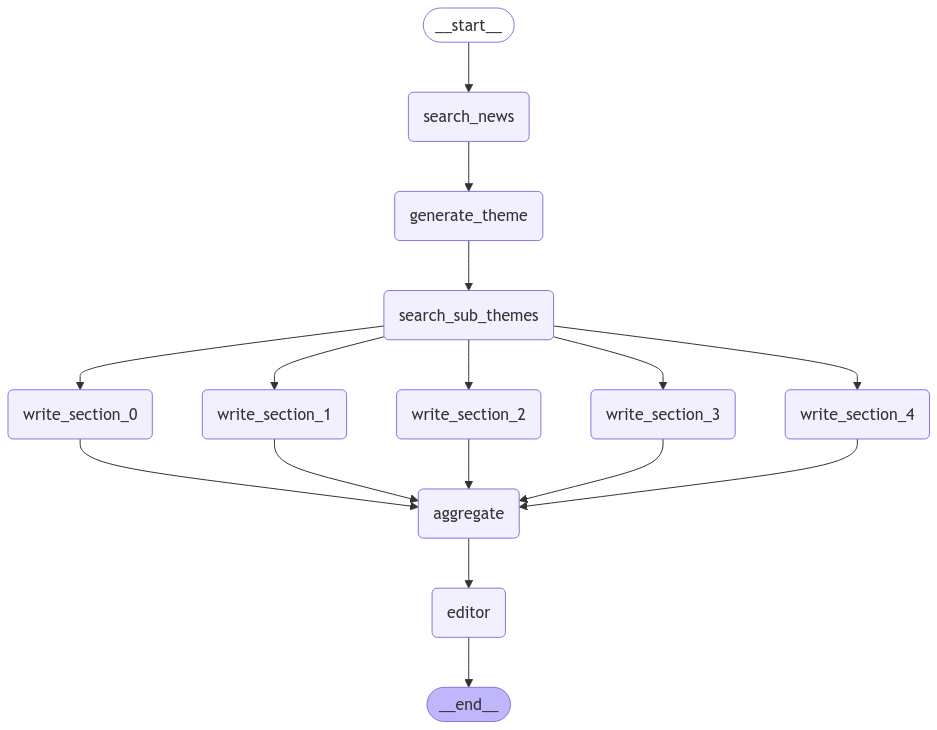

In [24]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
keyword = input("Enter a keyword for the newsletter:")

inputs = {"keyword": keyword}

async for output in graph.astream(inputs, stream_mode="updates"):
    for key, value in output.items():
        print(f"Output from node '{key}': ")
        print("---")
        print(print(value))
    print("\n---\n")

Output from node 'search_news': 
---
{'article_titles': ["OpenAI's lawyer says there are too many files from Ilya Sutskever and other employees to share in copyright lawsuit - Business Insider", 'ChatGPT rejected more than 250,000 image generations of presidential candidates prior to Election Day - NBC News', 'OpenAI reportedly facing issues with its new AI model is a red flag for the entire industry - Business Insider', 'OpenAI reportedly developing new strategies to deal with AI improvement slowdown - TechCrunch', 'Read the casual emails between Elon Musk and Sam Altman that kicked off OpenAI - Business Insider', "OpenAI plans to release an AI agent called 'Operator' to operate PCs on behalf of humans in January 2025 - GIGAZINE（ギガジン）", "Elon Musk says OpenAI's compensation is 'lavish.' Here's how much employees get paid. - Business Insider", 'OpenAI at one point considered acquiring AI chip startup Cerebras - TechCrunch', 'OpenAI co-founder Greg Brockman returns three months after le

In [21]:
keyword = input("Enter a keyword for the newsletter: ")

inputs = {"keyword": keyword}
async for output in graph.astream(inputs, stream_mode="updates"):
    
    # stream_mode="updates" yields dictionaries with output keyed by node name
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("---")
        print(print(value))
    print("\n---\n")

Output from node 'search_news':
---
{'article_titles': ["OpenAI's lawyer says there are too many files from Ilya Sutskever and other employees to share in copyright lawsuit - Business Insider", 'ChatGPT rejected more than 250,000 image generations of presidential candidates prior to Election Day - NBC News', 'OpenAI reportedly facing issues with its new AI model is a red flag for the entire industry - Business Insider', 'OpenAI reportedly developing new strategies to deal with AI improvement slowdown - TechCrunch', 'Read the casual emails between Elon Musk and Sam Altman that kicked off OpenAI - Business Insider', "OpenAI plans to release an AI agent called 'Operator' to operate PCs on behalf of humans in January 2025 - GIGAZINE（ギガジン）", "Elon Musk says OpenAI's compensation is 'lavish.' Here's how much employees get paid. - Business Insider", 'OpenAI at one point considered acquiring AI chip startup Cerebras - TechCrunch', 'OpenAI co-founder Greg Brockman returns three months after lea